# Сравнение open-source солверов для задач ритейла

**Проблема**

<p style="text-align: justify;">
В настоящее время многие задачи, связанные с ML моделированием окаймляются задачами оптимизации. Если вам необходимо сделать в сжатые сроки MVP на базе оптимизатора, то выбор часто падает на первый попавшийся солвер, который может работать неоптимально при масштабировании. В этой статье мы рассмотрим несколько открытых солверов, сравним их возможности и скорость работы на модельной задаче ценообразования.
</p>

Приведём несколько примеров задач, где могкт использоваться оптимизаторы.

***Оптимальное распределение маркетингового бюджета***
<p style="text-align: justify;">
Задача - реализовать выделенный бюджет на маркетинговые активности максимально эффективно. Есть несколько каналов для рекламных акций, выделенный бюджет, цель - максимально выгодно инвестировать бюджет, чтобы суммарный доход со всем коммуникаций был максимален. Также необходимо учесть бизнес ограничения на нагрузку каждого канала + частоту взаимодействия.
Планирование ассортимента
</p>

***Оптимизация ассортимента*** 
<p style="text-align: justify;">
...
</p>

***Закупка товаров***

<p style="text-align: justify;">
Задача - распределить бюджет выделенный на закупки для поддержания товарооборота, достаточного уровня сервиса, и при этом достигать определенных финансовых показателей под выделенный бюджет на закупки.
</p>

***Ценообразование***
<p style="text-align: justify;">
Поиск оптимальной конфигурации цен с учетом ценового позиционирования, допустимых ценовых диапазонов для каждого товара и набора бизнес-ограничений. Цены должны максимизировать суммарный доход, а прибыль быть не ниже на заданного уровня.
</p>



<p style="text-align: justify;">

Бывают случаи, когда применять методы оптимизации не имеет смысла. Хорошо известен случай, когда для снижения жалоб на ожидание лифта в многоэтажке оказались не оптимальное загрузка и не расписание, а решение повесить зеркало рядом с лифтом. Для успешного решения подобных задач необходимо плотное взаимодействие с экспертами, заказчиками и исследование проблемы в “полях”.
</p>


**Ограничения What-If анализа**
<p style="text-align: justify;">
Часто бизнес-заказчик ограничивается только What-If анализом для выбора лучших значений, найденных какой-то моделью. Приведём пример. Предположим, что спрос на товар зависит только от цены и определяется следующей моделью:

$$
{Q=Q}_0exp\left(E\left(\frac{P_0}{P}-1\right)\right).
$$

What-If инструмент для такой модели даст возможность либо найти максим по каждому товару, либо для заданной руками цены оценить $Q$. 


<p style="text-align: justify;">
    
Проблема в таком подходе - огромный объём ручной работы и невозможность явно учитывать бизнес-ограничения.
    
Рассмотрим пример, когда поступает задача - поднять суммарные продажи категории товаров на 2%. Пусть категория содержит N уникальных sku, и мы знаем эластичность E для каждого товара, тогда мы получим следующий результат: 



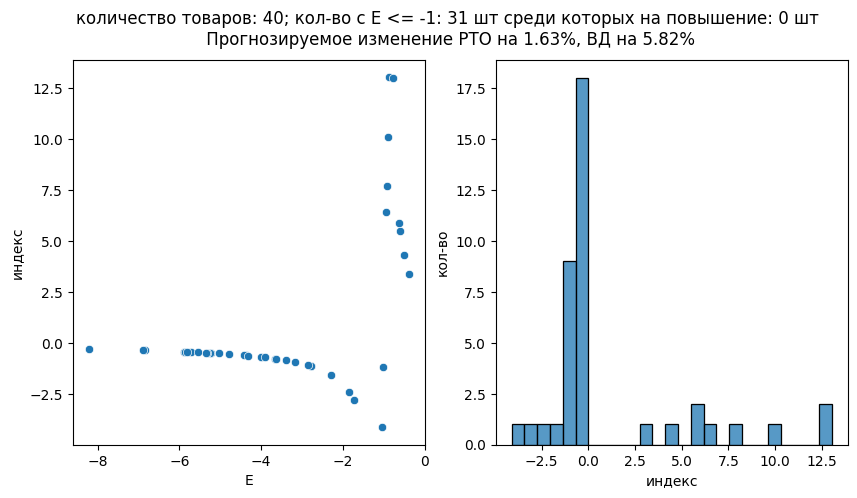

time: 513 ms (started: 2022-07-12 16:36:37 +03:00)


In [22]:
from data_generator.what_if import sim_data, plot_what_if

data_pricing = sim_data()
plot_what_if(data_pricing);

<p style="text-align: justify;">
Хорошо видно, что все для всех чувствительных товаров (E<-1) цена снизится и наоборот. Но многое товары имеют незначительные изменение, что может противоречить бизнес-ограничению на минимально допустимое изменение цены, или нивелироваться округлением цены до бизнес-правила, например, заканчиваться на x.99.

## Общая постановка задачи оптимизации

$$f(x) \rightarrow \min_{x}$$
$$g_{i}(x) \le 0, i=1..n,$$
$$h_{i}(x) = 0, i=1..m,$$
$$x \in X$$

$f(x)$ функция от цены, выраженной через ценовой индекс от текущей цены, $g$ и $h$ зависимости, отражающие бизнес-ограничения.

In [25]:
df = pd.read_csv('data/optimizers_stats.csv')

time: 3.19 ms (started: 2022-07-12 16:41:55 +03:00)


In [26]:
df

,N,seed,solver,t,status
0,10,0,slsqp,0.013617,ok
1,10,0,trust-constr,0.273943,ok
2,10,0,ipopt,0.044228,ok
3,10,0,pyomo_cbc,0.072709,ok
4,10,0,pyomo_glpk,0.040568,ok
...,...,...,...,...,...
115,50,4,pyomo_cbc,0.119818,ok
116,50,4,pyomo_glpk,0.079950,ok
117,50,4,cvxpy_cbc,0.026592,ok
118,50,4,cvxpy_glpk,0.013072,ok


time: 8.75 ms (started: 2022-07-12 16:41:58 +03:00)


In [23]:
! ls data

dump.hdf             optimizers_stats.csv
time: 138 ms (started: 2022-07-12 16:41:21 +03:00)


## Какие есть оптимизаторы?

Общая постановка задачи

Описание видов оптимизационных задач(постановки)


In [5]:
%load_ext autoreload
%autoreload 2
%load_ext autotime

time: 357 µs (started: 2022-07-12 16:33:28 +03:00)


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append('./OptimizersArticle')
from runner import DATA_DUMP, GRID, bounds_params, CvxpyLpOptimizationModel
from runner import optimizers_collect_stat, optimizers_calculate_stat


from data_generator.data_generator import (
    generate_data,
    construct_bounds,
    construct_lp_grid
)

from optimizers.optimization import pricing_optimization


time: 528 ms (started: 2022-07-12 16:33:28 +03:00)


In [7]:
optimizers_calculate_stat(GRID, DATA_DUMP)

time: 177 ms (started: 2022-07-12 16:33:28 +03:00)


In [8]:
stats_df = optimizers_collect_stat('./data/dump.hdf')

time: 1.66 s (started: 2022-07-12 16:33:29 +03:00)


### Отчет по времени работы и количеству "успешно" решенных задач

In [9]:
if 'stats_df' not in globals():
    stats_df = pd.read_csv('./data/optimizers_stats.csv')
stats_df['success'] = stats_df['status'] == 'ok'
time_rep_df = stats_df.groupby(['solver', 'N'])['t'].describe().reset_index()
stats_df

,N,seed,solver,t,status,success
0,10,0,slsqp,0.011506,ok,True
1,10,0,trust-constr,0.250120,ok,True
2,10,0,ipopt,0.045246,ok,True
3,10,0,pyomo_cbc,0.071532,ok,True
4,10,0,pyomo_glpk,0.041340,ok,True
...,...,...,...,...,...,...
2,500,9,pyomo_cbc,2.380126,ok,True
3,500,9,pyomo_glpk,1.047312,ok,True
4,500,9,cvxpy_cbc,0.626378,ok,True
5,500,9,cvxpy_glpk,1.105780,ok,True


time: 105 ms (started: 2022-07-12 16:33:30 +03:00)


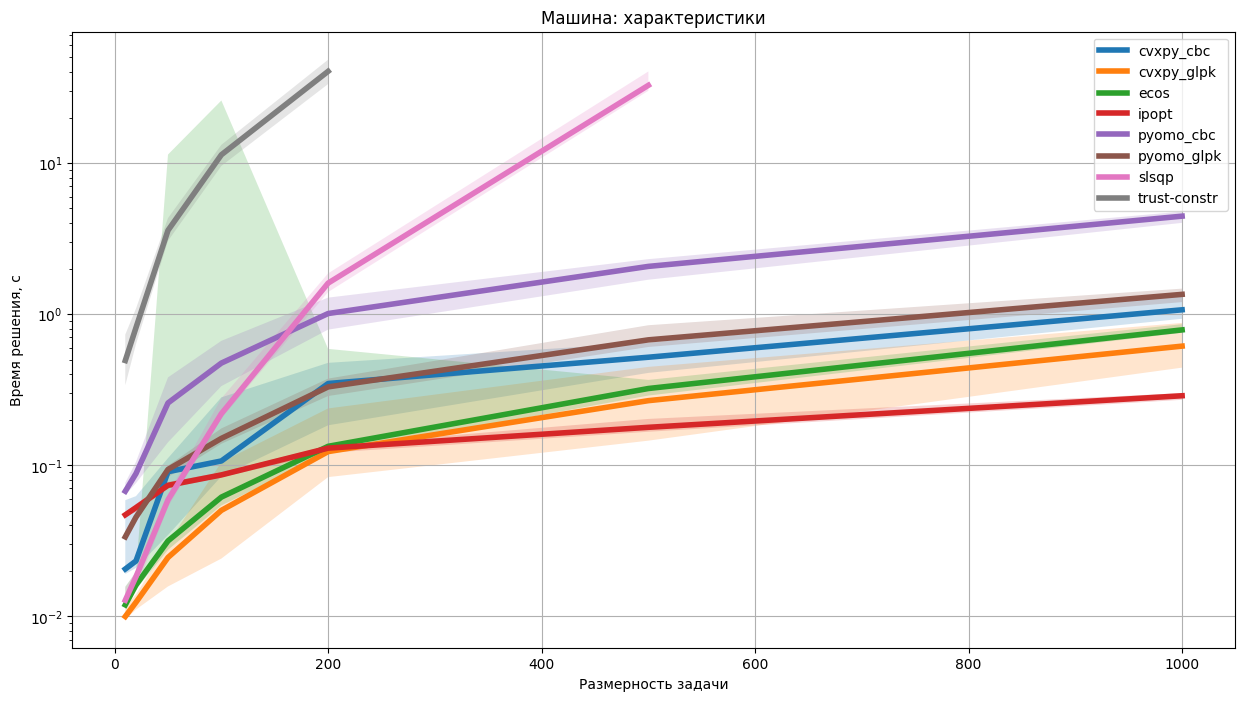

time: 579 ms (started: 2022-07-12 16:33:30 +03:00)


In [10]:
plt.figure(figsize=(15, 8))
for solver, df in time_rep_df.groupby(['solver']):
    plt.plot(df['N'], df['50%'], label=solver, lw=4)
    plt.fill_between(df['N'], df['25%'], df['75%'], alpha=0.2)
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.xlabel('Размерность задачи')
plt.ylabel('Время решения, с')
plt.grid()
plt.title("Машина: характеристики")
plt.show()


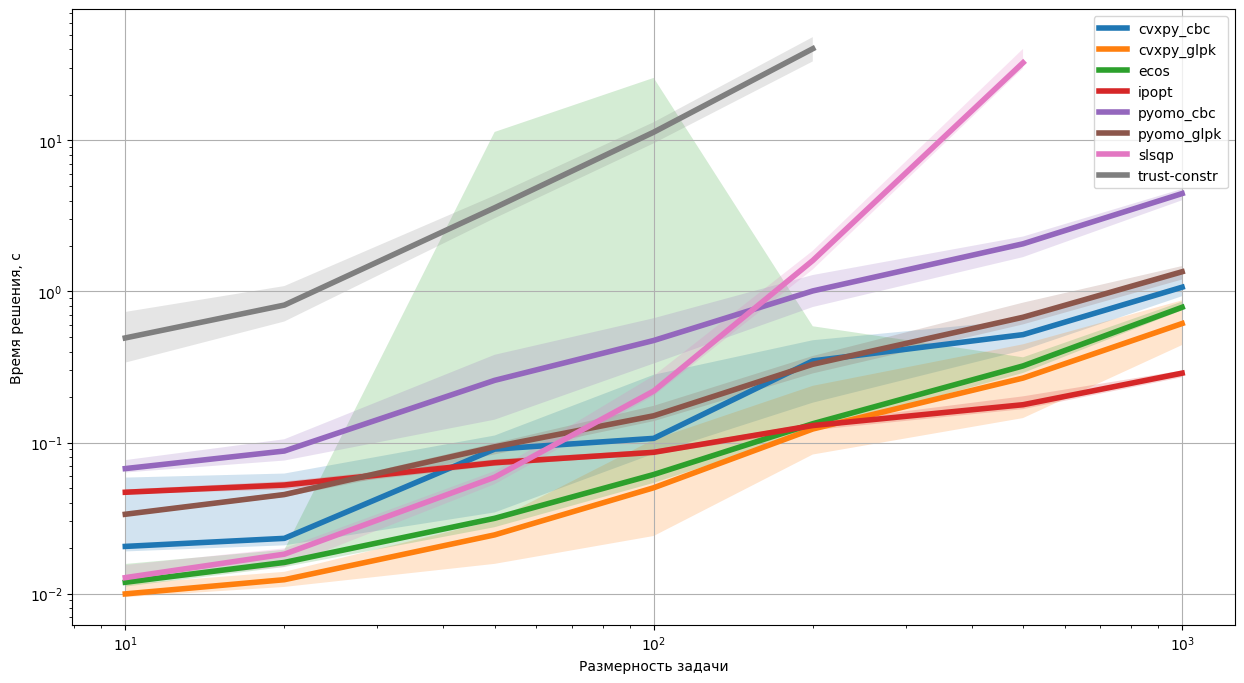

time: 586 ms (started: 2022-07-12 16:33:31 +03:00)


In [11]:
plt.figure(figsize=(15, 8))
for solver, df in time_rep_df.groupby(['solver']):
    plt.plot(df['N'], df['50%'], label=solver, lw=4)
    plt.fill_between(df['N'], df['25%'], df['75%'], alpha=0.2)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel('Размерность задачи')
plt.ylabel('Время решения, с')
plt.grid()
plt.show()


In [12]:
stats_df.groupby(['solver'])['success'].mean()


solver
cvxpy_cbc       1.000000
cvxpy_glpk      1.000000
ecos            0.777143
ipopt           1.000000
pyomo_cbc       1.000000
pyomo_glpk      1.000000
slsqp           1.000000
trust-constr    0.984000
Name: success, dtype: float64

time: 3.65 ms (started: 2022-07-12 16:33:32 +03:00)


In [13]:
stats_df.query("not success")

,N,seed,solver,t,status,success
7,10,1,ecos,2.058176,optimal_inaccurate,False
7,10,10,ecos,1.816445,infeasible_inaccurate,False
7,10,13,ecos,1.295665,infeasible_inaccurate,False
7,10,15,ecos,2.015468,optimal_inaccurate,False
7,10,18,ecos,1.238128,optimal_inaccurate,False
7,10,7,ecos,1.423704,optimal_inaccurate,False
7,100,12,ecos,27.818785,infeasible_inaccurate,False
7,100,13,ecos,28.930013,infeasible_inaccurate,False
7,100,14,ecos,28.531776,infeasible_inaccurate,False
7,100,16,ecos,33.227190,infeasible_inaccurate,False


time: 12.6 ms (started: 2022-07-12 16:33:32 +03:00)


In [14]:
data_c = generate_data(10, 1)
data_c = construct_bounds(data_c, bounds_params)
# генерация данных для MILP оптимизации
data_d = construct_lp_grid(data_c, bounds_params, 21)
M_cur = sum(data_c['Q'] * (data_c['P'] - data_c['C']))
P_cur = sum(data_c['Q'] * data_c['P'])

opt_params = {
    'alpha': 0.0,
    'con_mrg': M_cur,
    'con_equal': True
}

time: 39.4 ms (started: 2022-07-12 16:33:32 +03:00)


In [15]:
%%time
res_cvx, t_cvx = pricing_optimization(data_d, CvxpyLpOptimizationModel, opt_params, 'ECOS_BB',
                                      solver_option={'max_iters': 1000})
# res_cbc, t_cbc = pricing_optimization(data_d, PyomoLpOptimizationModel, opt_params, 'glpk')

CPU times: user 2.02 s, sys: 5.22 ms, total: 2.03 s
Wall time: 2.03 s
time: 2.03 s (started: 2022-07-12 16:33:32 +03:00)


/Users/antondnsv/work/X5/pricing/OptimizersArticle/venv/lib/python3.7/site-packages/cvxpy/problems/problem.py:1338: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  "Solution may be inaccurate. Try another solver, "


In [16]:
res_cvx['model'].solution.attr['solver_specific_stats']['info']

{'exitFlag': 10,
 'pcost': -1244.9889973994493,
 'dcost': -1244.9889973755776,
 'pres': 1.3508151719502032e-10,
 'dres': 1.3386534420411526e-11,
 'pinf': 0.0,
 'dinf': 0.0,
 'pinfres': nan,
 'dinfres': 2.621038967052042,
 'gap': 2.623831338936334e-07,
 'relgap': 2.1075136763594138e-10,
 'r0': 1e-08,
 'iter': 6,
 'mi_iter': 999,
 'infostring': 'Maximum iterations reached with feasible solution found',
 'timing': {'runtime': 0.000553353,
  'tsetup': 0.00014463,
  'tsolve': 0.000408723},
 'numerr': 0}

time: 2.63 ms (started: 2022-07-12 16:33:34 +03:00)


In [17]:
t_cvx

2.030345916748047

time: 1.79 ms (started: 2022-07-12 16:33:34 +03:00)


In [18]:
# (
#     sum(res_cbc['data']['P_opt'] * res_cbc['data']['Q_opt']), 
#     sum(res_cvx['data']['P_opt'] * res_cvx['data']['Q_opt'])
# )

time: 590 µs (started: 2022-07-12 16:33:34 +03:00)
